# Reaksjonsrater 2

## Frem-og-tilbake, fortsettelse

Husk sykloheksan fra forrige prosjekt. Vi fikk ligningssystemet

$$
\begin{align}
\frac{d[X_1]}{dt} &= -a[X_1] + b[X_2] \\
\frac{d[X_2]}{dt} &= a[X_1] - b[X_2]
\end{align}
$$

hvor $[X_1]$ er konsentrasjon av båt og $[X_2]$ er konsentrasjon av stol. Vi har

$$
a = A \exp\left(\frac{-E_a}{RT}\right),
$$

hvor $A=6.15\cdot 10^{11}$ s$^{-1}$, og $E_a=18$ kJ/mol. På lignende måte er

$$
b = B \exp\left(\frac{-E_b}{RT}\right),
$$

hvor $B = 1.48\cdot 10^{12}$ s$^{-1}$, og $E_b=43$ kJ/mol.

Hva skjer om vi diagonalisere systemet?

## Oppgave 1

1. Diagonaliser systemet
2. Finn en analytisk løsning til ligningssystemet
3. Hva skjer når tid $t\rightarrow\infty$?
4. Stemmer det overens med det du fant forrige gang?

## Løsning

Matrisa har egenverdier $\lambda = 0, -a-b$ og tilsvarende egenvektorer $(b,a)$ og $(1,-1)$. Dvs

$$
A = PDP^{-1}
$$

hvor

$$
P = \begin{pmatrix}
b & 1 \\
a & -1
\end{pmatrix}
$$

og

$$
D = \begin{pmatrix}
0 & 0 \\
0 & -a-b
\end{pmatrix}
$$

Den generelle løsningen tar formen
$$
X = c_0 
\begin{pmatrix}
b \\
a
\end{pmatrix}
+
c_1
\begin{pmatrix}
1 \\
-1
\end{pmatrix}
e^{-(a+b)t}
$$

Vi finner $\vec{c} = (c_0, c_1)$ ved å løse $P\vec{x}_0 = \vec{c}$. Det andre leddet kommer til å forsvinne i det $t\rightarrow\infty$

Vi kan forresten beregne
$$
P^{-1} = \frac{1}{a+b}\begin{pmatrix}
1 & 1 \\
a & -b
\end{pmatrix}
$$

Slik at 
$$
\vec{c} = P^{-1} (x_0,y_0)^T = \frac{1}{a+b}(x_0 + y_0, ax_0 - by_0)
$$

Dvs løsningen går mot
$$
\vec{x} = \frac{x_0 + y_0}{a+b}\begin{pmatrix}
b \\
a
\end{pmatrix}
$$

## Mer komplisert reaksjonskjeder

La oss betrakt en generell situasjon hvor vi har flere reaksjoner, hvor reaksjon $i$ beskrives av

$$
\sum_j s_{ij} X_j \rightarrow \sum_j r_{ij} X_j
$$

Vi definerer den støkiometriske matrisen $S_{ij} = s_{ij} - r_{ij}$. Vi får et ligningssystem:

$$
\frac{d[X_j]}{dt} = \sum_i f_i([X]) S_{ij} ,
$$

hvor $f_j([X])$ er reaksjonraten på reaksjon $j$. Hvis reaksjonen går begge veier med baklengs reaksjonsrate $b_j([X])$, får vi heller

$$
\frac{d[X_i]}{dt} = \sum_j\big( f_j([X]) - b_j([X]) \big) S_{ij} ,
$$

## Eksempel:

$$
2A + B \rightarrow C + D
$$
$$
A + C \rightarrow 2D + E
$$

Vi får en matrise
$$
\begin{pmatrix}
A & B & C & D & E \\
\hline
-2 & -1 & 1 & 1 & 0 \\
-1 & 0 & -1 & 2 & 1
\end{pmatrix}
$$

La oss anta at reaksjonsraten på den første er lik $k_1 [A]^2 [B]$, og på den andre $k_2 [A] [C]$. Da får vi

$$
\frac{d}{dt} ([A], [B], [C], [D], [E]) = (k_1 [A]^2 [B], k_2 [A] [C])
\begin{pmatrix}
2 & 1 & -1 & -1 & 0 \\
1 & 0 & 1 & -2 & -1
\end{pmatrix}
$$

Vi får:

$$
\frac{d[A]}{dt} = 2 k_1 [A]^2 [B] + k_2 [A] [C]
$$
$$
\frac{d[B]}{dt} = k_1 [A]^2 [B]
$$
$$
\frac{d[C]}{dt} = - k_1 [A]^2 [B] + k_2 [A] [C]
$$
$$
\frac{d[D]}{dt} = - k_1 [A]^2 [B] - 2k_2 [A] [C]
$$
$$
\frac{d[E]}{dt} = k_2 [A] [C]
$$


## Eksempel: BRUSSELATOR

En modell for en oscillerende (frem-og-tilbake) reaksjon (se for eksempel: https://en.wikipedia.org/wiki/Briggs–Rauscher_reaction) er følgende BRUSSELATOR:

$$ A \rightarrow X $$
$$ 2X + Y \rightarrow 3X $$
$$ B + X \rightarrow Y + D $$
$$ X \rightarrow E $$

Vi går ikke inn i detaljer på stoffene. Mer avanserte modeller eksisterer for spesifikke reaksjoner (se for eksempel http://www.scholarpedia.org/article/Oregonator), men de trenger vi ikke her.

Anta at (alle reaksjoner går bare forlengs):
1. Reaksjon 1 har rate $[A]$
2. Reaksjon 2 har rate $[X]^2 [Y]$
3. Reaksjon 3 har rate $[B][X]$
4. Reaksjon 4 har rate $[X]$

## Oppgave 2

1. Finn matrisa $S$ som beskriver reaksjonen over
2. Finn dermed ligningene for $\frac{d[X]}{dt}$ og $\frac{d[Y]}{dt}$ (det er vanlig å anta at de andre konsentrasjonene er tilnærmet konstant)
3. Løs systemet for forskjellige verdier av de konstante konsentrasjonene $[A],[B]$ ved hjelp av koden under
4. Kommenter resultatene

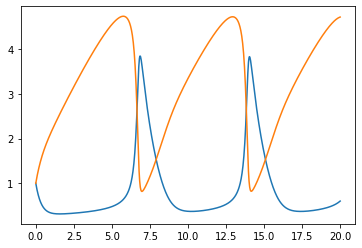

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def euler(f,x0,a,b,N):
    t = np.linspace(a,b,N)
    x = np.zeros((N,x0.size))
    x[0,:] = x0
    for i in np.arange(N-1):
        x[i+1,:] = x[i,:] + (t[i+1]-t[i])*(f(x[i],t[i]))
    return x,t

def brusselator(x,t):
    A = 1
    B = 3
    y = np.zeros(x.size)
    y[0] = A + (x[0]**2)*x[1] - B*x[0] - x[0]
    y[1] = B*x[0] - (x[0]**2)*x[1]
    return y

x, t = euler(brusselator, np.ones((2)), 0, 20, 1000)

fig, ax = plt.subplots()

ax.plot(t,x[:,0])
ax.plot(t,x[:,1])

## Løsning

Matrisa blir (vi tar rekkefølge $A,B,D,E,X,Y$)

$$
\begin{pmatrix}
-1 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 1 & -1 \\
0 & -1 & 1 & 0 & -1 & 1 \\
0 & 0 & 0 & 1 & -1 & 0
\end{pmatrix}
$$

Slik at
$$
\frac{d}{dt}([A],[B],[D],[E],[X],[Y])
=
([A], [X]^2 [Y], [B][X], [X])
\begin{pmatrix}
-1 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 1 & -1 \\
0 & -1 & 1 & 0 & -1 & 1 \\
0 & 0 & 0 & 1 & -1 & 0
\end{pmatrix}
$$

Vi får løsning ved å se på det siste 2 radene:
$$
\frac{d[X]}{dt} = [A] + [X]^2[Y] - [B][X] - [X]
$$
$$
\frac{d[Y]}{dt} = -[X]^2[Y] - [B][X]
$$